# 3. NDVI a vector (paramétrico)

Versión paramétrica de `3.ndvi_to_vector.ipynb`. Calcula estadísticas zonales de
NDVI por manzana (`rasterstats.zonal_stats`) y las agrega a la tabla de simulación.
Lógica idéntica al original; solo cambian las rutas (config).

**Entradas:** `manzanas_{zona}_sim.parquet` (nb 1) · `ndvi_{zona}.tif` (nb 0.1)

**Salida:** sobrescribe `manzanas_{zona}_sim.parquet` agregando columnas NDVI

`zonal_stats` reproyecta las manzanas al CRS del raster, así que funciona sin
importar si el NDVI está en 4326 (export original) o UTM 19S (nb 0.1).

---

In [1]:
import os
import sys
import importlib.util
from pathlib import Path

# Fix PROJ (mismo que nb 0.1 — evita CRSError por conflicto conda/pip)
for _pkg, _rel in (('rasterio', 'proj_data'), ('pyproj', 'proj_dir/share/proj')):
    _spec = importlib.util.find_spec(_pkg)
    if _spec is not None:
        _cand = Path(_spec.origin).parent / _rel
        if (_cand / 'proj.db').exists():
            os.environ['PROJ_LIB'] = os.environ['PROJ_DATA'] = str(_cand)
            break

sys.path.insert(0, str(Path('..').resolve()))
from config import ZONA, FP_MANZ_SIM, FP_NDVI

import geopandas as gpd
import pandas as pd
import rasterio
from rasterstats import zonal_stats

print(f'Zona: {ZONA}')

Zona: suroriente


In [2]:
# 1. Leer tabla de simulación (nb 1) y raster NDVI (nb 0.1)
manz_sim = gpd.read_parquet(FP_MANZ_SIM)
print(f'Dimensión base: {manz_sim.shape} | CRS base: {manz_sim.crs.to_epsg()}')

with rasterio.open(FP_NDVI) as src:
    print(f'CRS raster: {src.crs} | res: {src.res}')

Dimensión base: (6782, 9) | CRS base: 32719
CRS raster: EPSG:32719 | res: (10.0, 10.0)


In [3]:
# 2. Estadísticas zonales de NDVI por manzana
zs = zonal_stats(manz_sim, str(FP_NDVI),
                 stats=['mean', 'median', 'max'], nodata=None)
zs_df = pd.DataFrame(zs)

manz_sim['ndvi_mean']   = zs_df['mean'].values
manz_sim['ndvi_median'] = zs_df['median'].values
manz_sim['ndvi_max']    = zs_df['max'].values

# Normalización 0-1 para simulación (relativa a la zona)
mn, mx = manz_sim['ndvi_mean'].min(), manz_sim['ndvi_mean'].max()
manz_sim['ndvi_norm'] = (manz_sim['ndvi_mean'] - mn) / (mx - mn)

manz_sim['ndvi_q'] = pd.qcut(manz_sim['ndvi_mean'], 5,
                             labels=['Muy bajo', 'Bajo', 'Medio', 'Alto', 'Muy alto'])

In [4]:
# 3. Chequeos
print(manz_sim[['ndvi_mean', 'ndvi_median', 'ndvi_max', 'ndvi_norm']].describe())
print('\nNaN por columna:')
print(manz_sim[['ndvi_mean', 'ndvi_median', 'ndvi_max', 'ndvi_norm']].isna().mean())

         ndvi_mean  ndvi_median     ndvi_max    ndvi_norm
count  6782.000000  6782.000000  6782.000000  6782.000000
mean      0.175627     0.160473     0.417180     0.246449
std       0.087150     0.088079     0.170943     0.130518
min       0.011066     0.007069     0.036502     0.000000
25%       0.108106     0.091547     0.286035     0.145328
50%       0.165186     0.147794     0.401720     0.230813
75%       0.231326     0.216159     0.540714     0.329866
max       0.678793     0.772952     0.908637     1.000000

NaN por columna:
ndvi_mean      0.0
ndvi_median    0.0
ndvi_max       0.0
ndvi_norm      0.0
dtype: float64


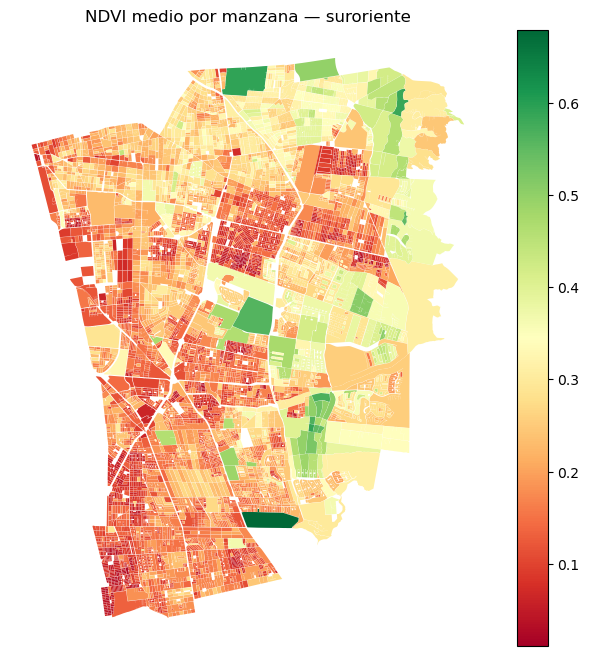

In [5]:
# 4. Mapa de control
import matplotlib.pyplot as plt
ax = manz_sim.plot(column='ndvi_mean', cmap='RdYlGn', legend=True, figsize=(8, 8))
ax.set_axis_off()
ax.set_title(f'NDVI medio por manzana — {ZONA}')
plt.show()

In [6]:
# 5. Sobrescribir archivo final con NDVI agregado
manz_sim_export = manz_sim.copy()
for col in manz_sim_export.select_dtypes(include='category').columns:
    manz_sim_export[col] = manz_sim_export[col].astype(str)

manz_sim_export.to_parquet(FP_MANZ_SIM)
manz_sim_export.to_file(FP_MANZ_SIM.with_suffix('.gpkg'),
                        layer='manzanas_sim', driver='GPKG')
print(f'Archivo actualizado con NDVI: {FP_MANZ_SIM}')

Archivo actualizado con NDVI: C:\Users\mbell\Desktop\UNIVERSIDAD\DOCTORADO\TESIS\REPOSITORIOS\simulador-am-tesis\data\processed\censo\manzanas_suroriente_sim.parquet
